# Comparaison du CNN et MLP sur le Cifar10 dataset.

### <font color='blue'>Importer les libraries et initialser une carte graphique (GPU) </font>

In [56]:
# Importer les libraries
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, AveragePooling2D, MaxPooling2D, Dropout
from tensorflow.keras.utils import to_categorical
import numpy as np
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


2024-01-20 12:34:02.466107: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-01-20 12:34:02.466324: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-01-20 12:34:02.466474: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

### <font color='blue'> Charger et explorer le jeu de données. Choisir un nombre limité de données pour l'entrainement. </font>

In [2]:
# Charger le jeu de données. (Pour comprendre plus sur ces données veillez visiter ce lien: https://www.cs.toronto.edu/~kriz/cifar.html)
cifar10 = tf.keras.datasets.cifar10 #(DONNÉES CIFAR)

(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = cifar10.load_data()
x_train_cifar, x_test_cifar = x_train_cifar / 255.0, x_test_cifar / 255.0

X_train shape:(50000, 32, 32, 3)
Y_train shape:(50000, 1)
X_test shape:(10000, 32, 32, 3)
Y_test shape:(10000, 1)


Text(0.5, 1.0, "Ceci est l'image de: [2]")

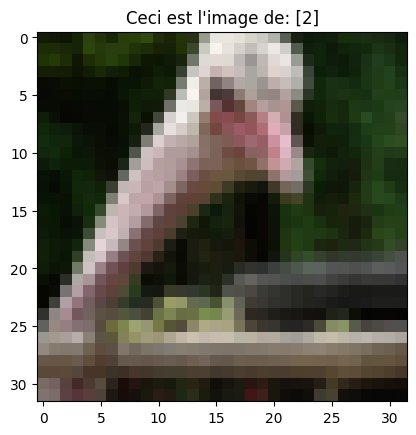

In [3]:
# Explorer le jeu de donnée
print('X_train shape:' + str(x_train_cifar.shape))
print('Y_train shape:' + str(y_train_cifar.shape))
print('X_test shape:' + str(x_test_cifar.shape))
print('Y_test shape:' + str(y_test_cifar.shape))

index_img = 502
plt.imshow(x_train_cifar[index_img,:,:])
plt.title('Ceci est l\'image de: '+str(y_train_cifar[index_img]))

In [4]:
# Choisir un nombre limité d'image pour votre entrainement (les 60000 images peuvent prendre
# trop de temps)
num_train_img = 50000

x_train_reduit = x_train_cifar[1:num_train_img,:,:]
y_train_reduit = y_train_cifar[1:num_train_img]

### <font color='blue'> Definir une fonction utilitaire pour plotter l'historique de l'entrainement. </font>

In [32]:
# Une fonction qui va permettre de plotter la fonction de cout et la performance
def plot_training_history(history, save_fig=False, fig_name=''):
    # Plot training & validation accuracy values
    plt.figure()
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    if save_fig:
        plt.savefig('accuracy' + fig_name + '.png')
    plt.show()

    plt.figure()
    # Plot training & validation loss values
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')
    if save_fig:
        plt.savefig('loss' + fig_name+ '.png')
    plt.show()
    

### <font color='blue'> Definir une fonction utilitaire pour faire de la prediction avec le modèle </font>

In [6]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Nous definissons une fonction qui fait la prediction (utilise tout simplement la list des objets)
def model_predict(model, img, true_label):
  plt.imshow(img)
  img = np.expand_dims(img, axis=0) # image size from (32,32,3) to (1, 32, 32, 3)
  y = model.predict(img)
  y_hat = np.argmax(y)
  print("The image is a: ", class_names[true_label[0]])
  print("The model predicted a: ", class_names[y_hat])



### <font color='blue'> Definir une fonction utilitaire pour entrainer le modèle <font>

In [53]:
# Nous definissons une fonction qui entraine le modèle en s'assurant que le GPU est utilisé
def train_net(net_func, num_epochs, lr, batch_size, gpu_device_name, train_images, train_labels, validation_split=0.2):
  # net_func: la fonction qui retourne le model
  # num_epochs: nombre d'époques
  # lr: taux d'apprentissage
  # gpu_device_name: le nom du GPU utilisé

  # Nous definissons l'entrainement de sorte qu'il utilise le GPU
  # L'algorithme d'optimisation et la fonction de coût sont aussi définie.
  strategy = tf.distribute.OneDeviceStrategy(gpu_device_name)
  with strategy.scope():
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr, weight_decay=1e-6)
    loss = tf.keras.losses.CategoricalCrossentropy()
    net = net_func()
    net.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

  history=net.fit(train_images, to_categorical(train_labels), batch_size=batch_size,epochs=num_epochs, verbose=1, validation_split=validation_split)
  return net, history # Le modèle entrainé est retourné en plus de l'historique de l'entrainement.

### <font color='blue'> Definir un modèle MLP </font
                                                  

In [8]:
# creer un modèle (un réseau de neurones)
def mlp():
  INPUT_SHAPE = (32,32, 3) # voir la taille des images affichée précédemment
  num_classes = 10

  #le modèle
  mon_model = Sequential()
  mon_model.add(Flatten(input_shape=INPUT_SHAPE)) #La couche qui recoit les images et les applati
  mon_model.add(Dense(120, activation='relu'))
  mon_model.add(Dense(84, activation='relu'))
  mon_model.add(Dense(num_classes, activation='softmax'))
  return mon_model

In [9]:
# Compiler le modèle (Definir la méthode d'optimisation et la fonction de coût)

# TACHES:
# changer la methode d'optimisation et les paramètres associés et observer le comportement
# Ajouter le momentum et observer le comportement
# Changer la structure de modèle plus( nombre de couche, nombre de neurones sur les couches, fonctions d'activation)
# Changer la fonction de coût à une fonction plus appropriée

lr = 0.0005 # 0.1 taux d'apprentissage
momentum = 0.9 #
#optimizer = tf.keras.optimizers.SGD(learning_rate=lr, momentum=momentum)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
loss='categorical_crossentropy'

#mon_model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

2024-01-20 04:00:49.573814: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-01-20 04:00:49.574526: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-01-20 04:00:49.575203: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

### <font color='blue'> Entrainer et tester le modèle. </font>

In [12]:
# Entrainer le modèle
nombre_epochs =300
batch_size = 64
#history = mon_model.fit(x_train_reduit, to_categorical(y_train_reduit), epochs=nombre_epochs, batch_size=12, verbose=2)
mlp_trained, history= train_net(mlp, nombre_epochs, lr, batch_size, device_name, x_train_reduit, y_train_reduit) # Training the network

2024-01-20 04:02:00.867786: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 614387712 exceeds 10% of free system memory.
2024-01-20 04:02:01.332021: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 614387712 exceeds 10% of free system memory.
2024-01-20 04:02:01.682228: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 614387712 exceeds 10% of free system memory.


Epoch 1/300


2024-01-20 04:02:02.761865: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f7c78fd05e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-01-20 04:02:02.761897: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 2070 with Max-Q Design, Compute Capability 7.5
2024-01-20 04:02:02.769613: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-01-20 04:02:02.793873: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
I0000 00:00:1705716122.907930   18575 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


782/782 [==============================] - 4s 3ms/step - loss: 1.8775 - accuracy: 0.3258
Epoch 2/300
782/782 [==============================] - 2s 3ms/step - loss: 1.6930 - accuracy: 0.3962
Epoch 3/300
782/782 [==============================] - 2s 3ms/step - loss: 1.6213 - accuracy: 0.4215
Epoch 4/300
782/782 [==============================] - 2s 3ms/step - loss: 1.5635 - accuracy: 0.4477
Epoch 5/300
782/782 [==============================] - 2s 3ms/step - loss: 1.5271 - accuracy: 0.4582
Epoch 6/300
782/782 [==============================] - 2s 3ms/step - loss: 1.4959 - accuracy: 0.4717
Epoch 7/300
782/782 [==============================] - 2s 3ms/step - loss: 1.4718 - accuracy: 0.4771
Epoch 8/300
782/782 [==============================] - 2s 3ms/step - loss: 1.4508 - accuracy: 0.4852
Epoch 9/300
782/782 [==============================] - 2s 3ms/step - loss: 1.4365 - accuracy: 0.4896
Epoch 10/300
782/782 [==============================] - 2s 3ms/step - loss: 1.4204 - accuracy: 0.4954
E

KeyboardInterrupt: 

In [ ]:
# Utiliser notre fonction plot_training_history pour afficher l'évolution de la fonction de coût
print(history.history.keys())
plot_training_history(history)

In [ ]:
# Evaluer le modèle sur les données d'entrainement et test
mlp_trained.evaluate(x_train_reduit, to_categorical(y_train_reduit))
mlp_trained.evaluate(x_train_cifar, to_categorical(y_train_cifar))
mlp_trained.evaluate(x_test_cifar, to_categorical(y_test_cifar))


In [ ]:
index_img = 105
image = x_test_cifar[index_img,:,:,:]
image_etiquette = y_test_cifar[index_img]

model_predict(mlp_trained,image , image_etiquette)

### <font color='blue'> Definir un CNN

In [ ]:
# premier modèle CNN
def lenet0():
  model = Sequential();
  model.add(Conv2D(input_shape=(32,32,3), filters=6, kernel_size=5, padding="same", activation="sigmoid"))
  model.add(AveragePooling2D(pool_size=2, strides=2))
  model.add(Conv2D(filters=16, kernel_size=5, activation='sigmoid'))
  model.add(AveragePooling2D(pool_size=2, strides= 2))
  model.add(Flatten())
  model.add(Dense(120, activation="sigmoid"))
  model.add(Dense(84, activation="sigmoid"))
  model.add(Dense(10, activation='softmax'))
  return model

In [76]:
# Un autre modèle CNN LeNet
def lenet1():
    model = Sequential()
    model.add(Conv2D(32, kernel_size=(3,3), strides=(1,1), activation='relu', input_shape=(32,32,3), padding='same'))
    model.add(Conv2D(32, kernel_size=(3,3), strides=(1,1), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
              
    model.add(Conv2D(64, kernel_size=(3,3), strides=(1,1), activation='relu', padding='same'))
    model.add(Conv2D(64, kernel_size=(3,3), strides=(1,1), activation='relu'))
    model.add(MaxPooling2D(pool_size=(4,4), strides=(2,2)))
    model.add(Flatten())

    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(10, activation='softmax'))
    return model

In [77]:
# Verifier le model
model = lenet1()
model.summary()

Model: "sequential_22"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_70 (Conv2D)          (None, 32, 32, 32)        896       
                                                                 
 conv2d_71 (Conv2D)          (None, 30, 30, 32)        9248      
                                                                 
 max_pooling2d_38 (MaxPooli  (None, 15, 15, 32)        0         
 ng2D)                                                           
                                                                 
 conv2d_72 (Conv2D)          (None, 15, 15, 64)        18496     
                                                                 
 conv2d_73 (Conv2D)          (None, 13, 13, 64)        36928     
                                                                 
 max_pooling2d_39 (MaxPooli  (None, 5, 5, 64)          0         
 ng2D)                                               

### <font color='blue'> Entrainer et evaluer le modèle </font>

In [79]:
# Entrainement du modèle
lr = 0.0001
epochs = 150
batch_size = 32
cnn_trained, cnn_history= train_net(lenet1, epochs, lr, batch_size, device_name, x_train_reduit, y_train_reduit) # Training the network


Epoch 1/150
1250/1250 [==============================] - 10s 6ms/step - loss: 1.9732 - accuracy: 0.2656 - val_loss: 1.6145 - val_accuracy: 0.4246
Epoch 2/150
1250/1250 [==============================] - 7s 5ms/step - loss: 1.6491 - accuracy: 0.3980 - val_loss: 1.4531 - val_accuracy: 0.4762
Epoch 3/150
1250/1250 [==============================] - 9s 7ms/step - loss: 1.5169 - accuracy: 0.4461 - val_loss: 1.3708 - val_accuracy: 0.5161
Epoch 4/150
1250/1250 [==============================] - 11s 8ms/step - loss: 1.4240 - accuracy: 0.4855 - val_loss: 1.2842 - val_accuracy: 0.5413
Epoch 5/150
1250/1250 [==============================] - 10s 8ms/step - loss: 1.3478 - accuracy: 0.5162 - val_loss: 1.2237 - val_accuracy: 0.5714
Epoch 6/150
1250/1250 [==============================] - 9s 7ms/step - loss: 1.2862 - accuracy: 0.5440 - val_loss: 1.1502 - val_accuracy: 0.5991
Epoch 7/150
1250/1250 [==============================] - 9s 7ms/step - loss: 1.2299 - accuracy: 0.5659 - val_loss: 1.1418 - val

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


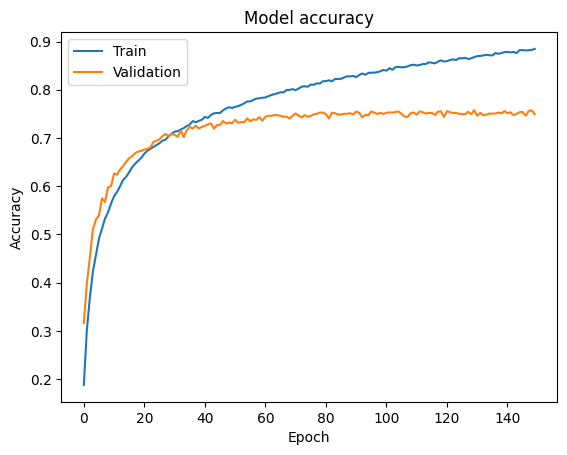

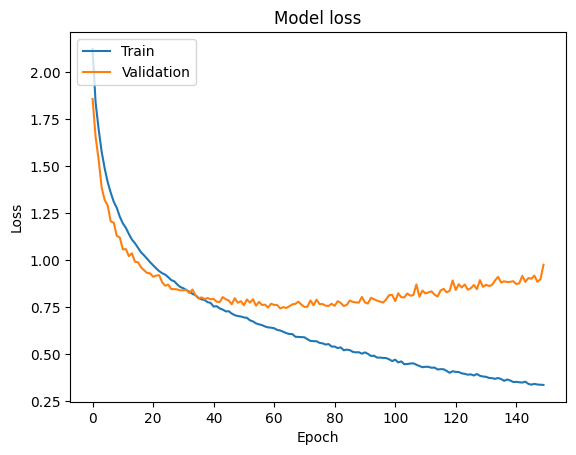

In [71]:
# Utiliser notre fonction plot_training_history pour afficher l'évolution de la fonction de coût
print(cnn_history.history.keys())
plot_training_history(cnn_history, save_fig= False, fig_name='cnn1')
cnn_trained.save("test.h5")

In [16]:
cnn_trained.evaluate(x_train_reduit, to_categorical(y_train_reduit))
cnn_trained.evaluate(x_train_cifar, to_categorical(y_train_cifar))
cnn_trained.evaluate(x_test_cifar, to_categorical(y_test_cifar))

313/313 [==============================] - 1s 2ms/step - loss: 1.2105 - accuracy: 0.6201


[1.2105045318603516, 0.6201000213623047]